# Лабораторная работа  
## Наивный Байес

**Название метода:** Наивный Байес для задачи классификации качества вина.

**Краткая информация о методе:**  
Наивный Байес — это простой вероятностный алгоритм классификации.  
Он оценивает вероятность принадлежности объекта к каждому классу и выбирает наиболее вероятный класс.  
Метод называется *наивным*, потому что предполагает независимость признаков друг от друга.  
В данной работе используется `GaussianNB`, так как большинство признаков являются числовыми.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Описание датасета

В работе используется датасет **Wine Quality**, объединяющий данные по красному и белому вину.

**Что предсказывается:**  
`quality_label` — бинарная оценка качества вина:
- `1` — хорошее вино;
- `0` — обычное или низкое качество.

**Почему этот датасет подходит:**
- в нём **6497 объектов**, то есть данных достаточно много;
- признаки понятные: кислотность, содержание спирта, плотность, количество диоксида серы и другие физико-химические характеристики;
- задача является **классификацией**, а Наивный Байес хорошо подходит для таких задач.


In [2]:
data_path_candidates = [
    Path("naive_bayes_wine_quality.csv"),
    Path("/mnt/data/naive_bayes_wine_quality.csv"),
]

for path in data_path_candidates:
    if path.exists():
        data_path = path
        break
else:
    raise FileNotFoundError("Файл naive_bayes_wine_quality.csv не найден.")

df = pd.read_csv(data_path)

print("Используемый файл:", data_path)
print("Размер датасета:", df.shape)
df.head()

Используемый файл: naive_bayes_wine_quality.csv
Размер датасета: (6497, 14)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type,quality_label
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,white,1
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,white,1
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,white,1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white,1
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white,1


In [3]:
print("Названия столбцов:")
print(df.columns.tolist())

print("\nТипы данных:")
print(df.dtypes)

print("\nКоличество пропусков по столбцам:")
print(df.isnull().sum())

Названия столбцов:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'wine_type', 'quality_label']

Типы данных:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
wine_type                   str
quality_label             int64
dtype: object

Количество пропусков по столбцам:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates              

Распределение классов:
quality_label
1    4113
0    2384
Name: count, dtype: int64


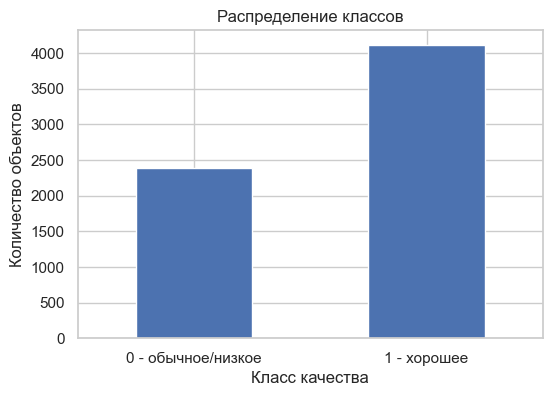

In [4]:
print("Распределение классов:")
print(df["quality_label"].value_counts())

plt.figure(figsize=(6, 4))
df["quality_label"].value_counts().sort_index().plot(kind="bar")
plt.title("Распределение классов")
plt.xlabel("Класс качества")
plt.ylabel("Количество объектов")
plt.xticks([0, 1], ["0 - обычное/низкое", "1 - хорошее"], rotation=0)
plt.show()

## 2. Предобработка данных

В данной работе есть и числовые, и категориальные признаки.

**Важно:**  
Столбец `quality` исключается из признаков, потому что `quality_label` построен на его основе.  
Если оставить `quality` в признаках, получится утечка данных: модель будет получать почти готовый ответ.


In [6]:
# Признаки и целевая переменная
X = df.drop(columns=["quality_label", "quality"])
y = df["quality_label"]

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

print("Числовые признаки:", numeric_features)
print("Категориальные признаки:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Числовые признаки: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Категориальные признаки: ['wine_type']
Размер обучающей выборки: (5197, 12)
Размер тестовой выборки: (1300, 12)


## 3. Тепловая карта корреляций

Ниже показана тепловая карта корреляций **числовых признаков** и целевой переменной `quality_label`.  
Для корректной интерпретации в карту не включается столбец `quality`, чтобы не было утечки данных.


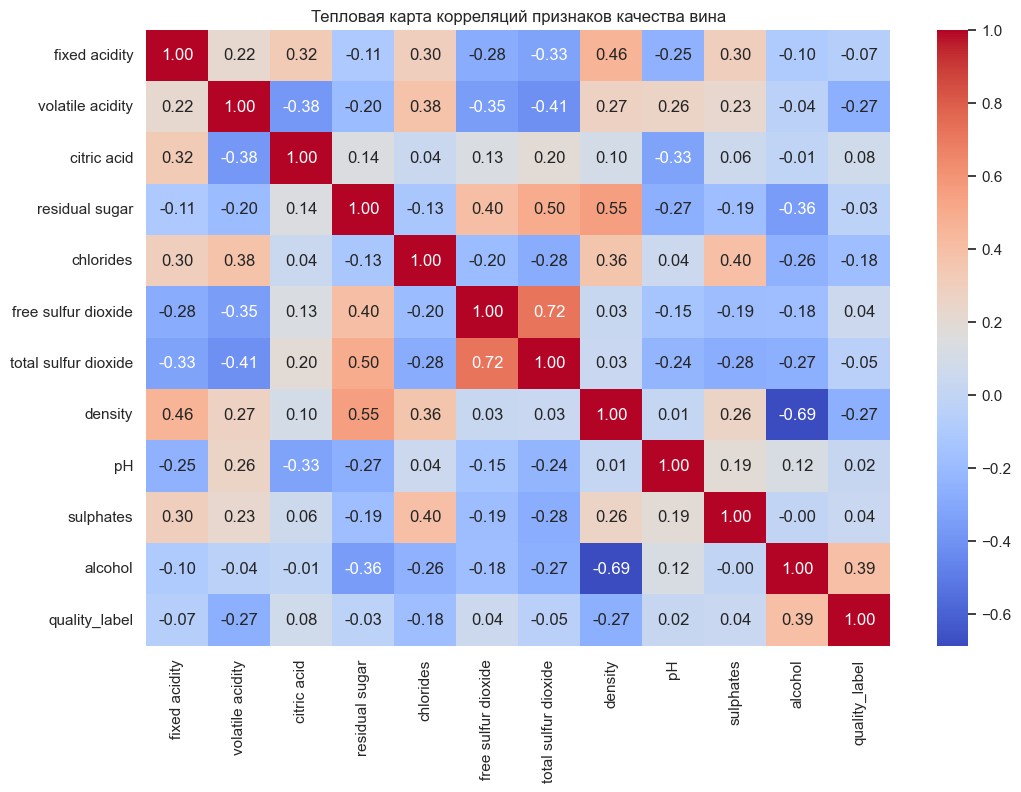

Признаки с наиболее заметной связью с целевой переменной:
alcohol                 0.394676
density                -0.268876
volatile acidity       -0.267046
chlorides              -0.181908
citric acid             0.075739
fixed acidity          -0.067354
total sulfur dioxide   -0.047585
free sulfur dioxide     0.044819
Name: quality_label, dtype: float64


In [7]:
corr_df = df.drop(columns=["quality"]).copy()
numeric_corr_cols = corr_df.select_dtypes(include=["int64", "float64"]).columns.tolist()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_df[numeric_corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Тепловая карта корреляций признаков качества вина")
plt.show()

target_corr = corr_df[numeric_corr_cols].corr()["quality_label"].drop("quality_label").sort_values(key=lambda x: x.abs(), ascending=False)

print("Признаки с наиболее заметной связью с целевой переменной:")
print(target_corr.head(8))

## 4. Обучение модели

Используется модель `GaussianNB`.  
Сначала выполняется предобработка признаков, затем модель обучается на обучающей выборке.


In [8]:
nb_clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", GaussianNB())
])

nb_clf.fit(X_train, y_train)
y_pred = nb_clf.predict(X_test)

print("Первые 10 предсказаний модели:")
print(y_pred[:10])

Первые 10 предсказаний модели:
[1 1 1 1 1 0 1 1 1 1]


## 5. Оценка качества модели

In [9]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nПодробный отчёт по классификации:")
print(classification_report(y_test, y_pred, target_names=["обычное/низкое", "хорошее"]))

Accuracy:  0.6908
Precision: 0.7213
Recall:    0.8335
F1-score:  0.7734

Подробный отчёт по классификации:
                precision    recall  f1-score   support

обычное/низкое       0.61      0.44      0.51       477
       хорошее       0.72      0.83      0.77       823

      accuracy                           0.69      1300
     macro avg       0.66      0.64      0.64      1300
  weighted avg       0.68      0.69      0.68      1300



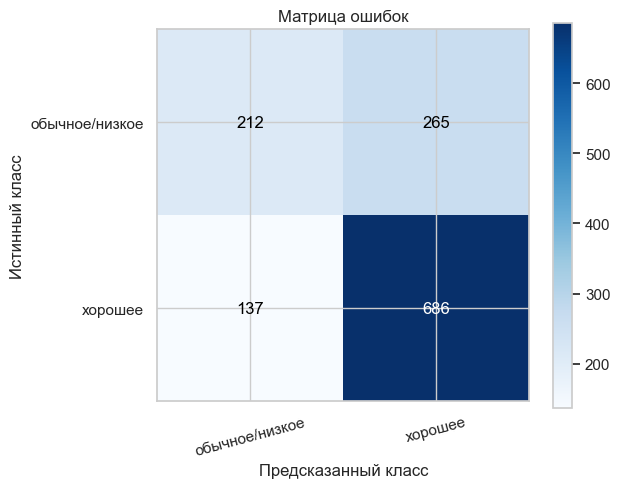

Матрица ошибок:
[[212 265]
 [137 686]]


In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Матрица ошибок")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.xticks([0, 1], ["обычное/низкое", "хорошее"], rotation=15)
plt.yticks([0, 1], ["обычное/низкое", "хорошее"])

threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > threshold else "black"
        plt.text(j, i, cm[i, j], ha="center", va="center", color=color, fontsize=12)

plt.colorbar()
plt.show()

print("Матрица ошибок:")
print(cm)

In [11]:
metrics = pd.DataFrame({
    "Метрика": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Значение": [accuracy, precision, recall, f1]
})

metrics

,Метрика,Значение
0,Accuracy,0.690769
1,Precision,0.721346
2,Recall,0.833536
3,F1-score,0.773393


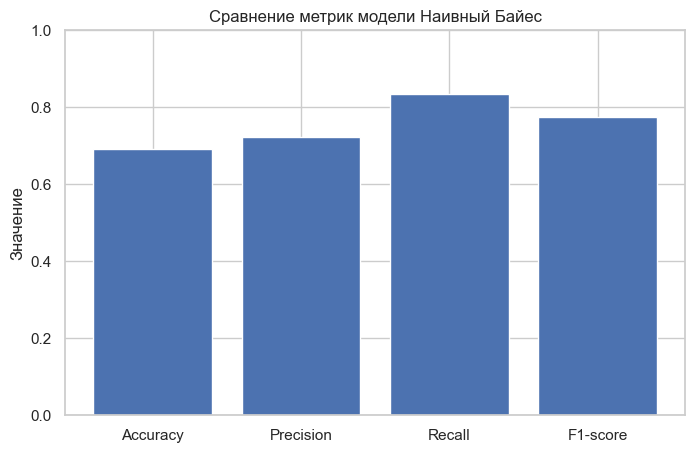

In [12]:
plt.figure(figsize=(8, 5))
plt.bar(metrics["Метрика"], metrics["Значение"])
plt.ylim(0, 1)
plt.title("Сравнение метрик модели Наивный Байес")
plt.ylabel("Значение")
plt.show()

## 6. Примеры прогнозов модели

In [13]:
results = X_test.copy()
results["Истинный класс"] = y_test.values
results["Предсказанный класс"] = y_pred

results["Истинный класс"] = results["Истинный класс"].map({0: "обычное/низкое", 1: "хорошее"})
results["Предсказанный класс"] = results["Предсказанный класс"].map({0: "обычное/низкое", 1: "хорошее"})

results.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,wine_type,Истинный класс,Предсказанный класс
1039,7.5,0.17,0.34,1.40,0.035,13.0,102.0,0.99180,3.05,0.74,11.0,white,обычное/низкое,хорошее
2446,6.6,0.32,0.33,2.50,0.052,40.0,210.0,0.99316,3.15,0.60,10.0,white,обычное/низкое,хорошее
3067,7.3,0.28,0.42,1.20,0.033,29.0,142.0,0.99205,3.17,0.43,10.7,white,обычное/низкое,хорошее
1785,8.5,0.21,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,white,хорошее,хорошее
4570,5.8,0.29,0.15,1.10,0.029,12.0,83.0,0.98980,3.30,0.40,11.4,white,хорошее,хорошее
5912,8.0,0.58,0.16,2.00,0.120,3.0,7.0,0.99454,3.22,0.58,11.2,red,хорошее,обычное/низкое
5395,7.2,0.34,0.32,2.50,0.090,43.0,113.0,0.99660,3.32,0.79,11.1,red,обычное/низкое,хорошее
1528,7.4,0.27,0.49,1.10,0.037,33.0,156.0,0.99200,3.15,0.54,11.1,white,хорошее,хорошее
4211,7.1,0.38,0.42,11.80,0.041,32.0,193.0,0.99624,3.04,0.49,10.0,white,хорошее,хорошее
5842,8.3,0.30,0.49,3.80,0.090,11.0,24.0,0.99498,3.27,0.64,12.1,red,хорошее,хорошее


## 7. Вывод

В данной лабораторной работе был рассмотрен метод **Наивный Байес** для задачи классификации качества вина.

По результатам эксперимента можно сделать вывод:
- модель успешно обучается на датасете из нескольких тысяч объектов;
- Наивный Байес способен решать задачу бинарной классификации на основе физико-химических признаков вина;
- наиболее заметное влияние на класс качества оказывают такие признаки, как содержание спирта, летучая кислотность, плотность и уровень сульфатов.

**Итог:** метод Наивного Байеса подходит для этой задачи как простой и понятный базовый классификатор.
